In [16]:
%load_ext autoreload
%autoreload 2

import sys
import os
import re
import json

import pandas as pd

import validation
import new_step1_ps
import performance_study as fmea_ps

from sentence_transformers import SentenceTransformer
import re
from dotenv import load_dotenv
from genai.credentials import Credentials
import performance_study as fmea_ps

pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

val_model = SentenceTransformer('all-mpnet-base-v2')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Methods

In [17]:
def build_cand_col_name(llm_model, prefix, suffix=None):
    """Construct candidate column name from llm_model and perm"""
    model_name = llm_model['name'].split("/")[-1]
    if suffix:
        cand_col_name = 'fls_' + model_name + '_' + str(suffix)
    else:
        cand_col_name = 'fls_' + model_name
    return prefix+cand_col_name

def process_model_perm(llm_model,
                  step_1_data,
                  dynamic_shots_cfg,
                  exp_conf,
                  permutation=None):
    """Generate output for model 'llm_model' and calculate metrics."""
    model_name = llm_model['name'].split("/")[-1]
    print("Model:", model_name)
    print("Permutation:", permutation)
    cand_col_name = build_cand_col_name(llm_model, "dfsp_", permutation)
    step_1_data[cand_col_name] = ""        
    dfsp_fls, raw_responses = new_step1_ps.generate_components_baseline(step_1_data["short_descriptions"],
                                                dynamic_shots_cfg,
                                                max_num_egs_in_prompt=exp_conf["max_num_shots"])


    step_1_data[cand_col_name + '_raw'] = raw_responses
    step_1_data[cand_col_name] = dfsp_fls

    return step_1_data

exp_conf = {
    "train_data" : "./data/all_ids_deduplicated_train_short_desc_to_failure_locations.csv",
    "val_data" : "./data/all_ids_deduplicated_val_short_desc_to_failure_locations.csv",
    "test_data" : "./data/all_ids_deduplicated_test_short_desc_to_failure_locations.csv",
    "max_num_shots" : 1, # Max number of shots or examples to include in the prompt (-1 equates to one random example).
    "decoding_method" : "greedy",
    "max_new_tokens" : 250,
    "repetition_penalty" : 1.2,
    "description" : "new prompt"
}

# Run baseline 
llm_model= {
        "name" : "local/Retreival-BestMatch",
        "prompt_func" : "dummay_prompt",
        "output_parser" : "dummpy_parser"
    }

step_1_data = pd.read_csv(exp_conf['val_data'])
step_1_data.rename(columns={'failure_locations':'gold_failure_locations'}, inplace=True)
step_1_data.rename(columns={'TypeData.GenCompType':'short_descriptions'}, inplace=True)
perm = exp_conf['max_num_shots']

dynamic_shots_cfg = fmea_ps.setup_few_shot_retrieval(train_data_path=exp_conf["train_data"],
                                                                   query_column='TypeData.GenCompType')

# adding baseline
model_name = 'Retreival-BestMatch'
print("Model:", model_name)
cand_col_name = build_cand_col_name(llm_model, "dfsp_", perm)
step_1_data = process_model_perm(llm_model, step_1_data, dynamic_shots_cfg, exp_conf, perm)
print ('Completed Result')

In [ ]:
step_1_data = validation.calculate_metrics(step_1_data, val_model, cand_col_name)

## Results
### Overall Results

,prec_dfsp_fls_Retreival-BestMatch_3
mean,0.468077
std,0.318891
min,0.000000
25%,0.192012
50%,0.414634
75%,0.730263
max,1.000000


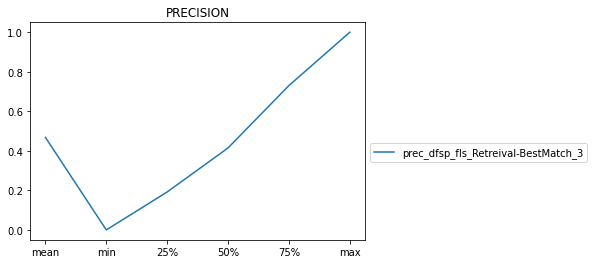

In [ ]:
table, plot = validation.get_precision_results(step_1_data)
display(table)
display(plot)

,rec_dfsp_fls_Retreival-BestMatch_3
mean,0.769315
std,0.309893
min,0.000000
25%,0.585714
50%,0.947368
75%,1.000000
max,1.000000


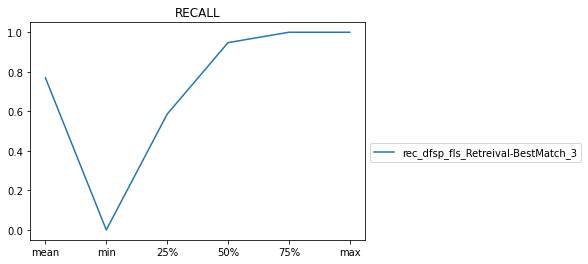

In [ ]:
table, plot = validation.get_recall_results(step_1_data)
display(table)
display(plot)

Unsorted:
- F1: 0.6391079298901337 	 dfsp_fls_flan-ul2-pt-CIAfuQo8-2024-04-05-14-24-04_(0, 1, 2)
- F1: 0.6339425454952703 	 dfsp_fls_flan-ul2-pt-a9WAHSDw-2024-04-05-09-44-06_(0, 1, 2)
- F1: 0.6272964424694355 	 dfsp_fls_flan-ul2_(0, 1, 2)
- F1: 0.6200929091789549 	 dfsp_fls_flan-ul2-pt-WIcurhNI-2024-04-10-15-19-24_(0, 1, 2)
- F1: 0.5257367173592123 	 dfsp_fls_granite-13b-instruct-v2_(0, 1, 2)
- F1: 0.04507216244872118 	 dfsp_fls_granite-13b-instruct-v2-pt-TDuGUCvq-2024-04-08-09-34-07_(0, 1, 2)

F1: 0.4296848591017088 	 dfsp_fls_mixtral-8x7b-instruct-v0-1_(0, 1, 2)
F1: 0.18210611368293977 	 dfsp_fls_mixtral-8x7b-instruct-v0-1_(0, 1, 2)

In [ ]:
prec_cols = [col for col in step_1_data if col.startswith('prec_')]
cand_col_names = [col[5:] for col in prec_cols]
f1_results = []
for col in cand_col_names:
    f1 = validation.calculate_overall_f1(step_1_data,col)
    f1_results.append((f1, col))
f1_results.sort(reverse=True)
for res in f1_results:
    print("F1:", res[0], '\t', res[1])



F1: 0.5820283744025664 	 dfsp_fls_Retreival-BestMatch_3


## Store Results

In [14]:
step_1_data.to_csv("results_df_baseline_top_1_val.csv")

In [15]:
step_1_data

TypeData.CompTypeID  \
0                                           BATT_CHGR_1   
1                                           Bumper_1_V0   
2                                    CBL_Power_Buried_3   
3                                    CBL_Power_Buried_8   
4                          CBL_PWR_PLT_BLK_EPR_DuctNS_2   
5                       CBL_PWR_PLT_BRN_EPR_DR_DuctNS_1   
6                              CBL_PWR_PLT_BUTYL_Duct_1   
7                            CBL_PWR_PLT_TR_XLPE_Duct_2   
8                                CNC_ContainerStacker_1   
9                                            COMP_Air_2   
10                                           CPLG_RBR_1   
11                                        CPLG_RBR_6_V0   
12                                          DG_IC_TSW_2   
13                                DG_SWGR_MCC_Starter_1   
14                                  Diesel_Engine_T4_V0   
15                                          Dryer_Air_2   
16                                          Fan_Large_1   
17                                          Fan_Large_2   
18                                    FanandMotor_Fin_2   
19                                    FanandMotor_Fin_3   
20                                         Filter_Air_1   
21             FLEX_COMP_PORT_GenUse_SCREW_T4_Diesel_V0   
22            FLEX_PMP_HORZ_OilBathSeal_T3DPF_Diesel_V0   
23               FLEX_PMP_HORZ_OilBathSeal_T4_Diesel_V0   
24            FLEX_PMP_HORZ_PackingSeal_T3DPF_Diesel_V0   
25       FLEX_PMP_LP_Packing_DirectDrv_IT4DPF_Diesel_V0   
26                                    Gearbox_Worm_2_V0   
27                    GEN_3600_SmoothRotor_AirCooled_V0   
28              GT_Fuel_Gas_GasControlValve&Actuator_V0   
29       GT_HRSG_DuctBurner_MainGasIsoValve&Actuator_V0   
30                               GT_HRSG_HP_Horz3stg_V0   
31                                 GT_LubeOil_PumpAC_V0   
32                      HVAC_Expansion_Joint_Metal_1_V0   
33                                       HX_FWH_LP_3_V0   
34                       IC_Flow_Level_SW_ThermElect_V0   
35                                          IC_TSW_1_V4   
36                                            LA_Dist_1   
37                                         LTC_PLT_2_V0   
38                                         LTC_Sub_1_V2   
39                                      MTR_LVVert_4_V2   
40                                      MTR_MVHorz_1_V3   
41                                      MTR_MVHorz_2_V3   
42                                      MTR_MVVert_8_V0   
43                                       PMP_HORZ_2A_V0   
44                                       PMP_HORZ_2G_V0   
45                                       PMP_HORZ_4D_V0   
46                                       PMP_HORZ_6B_V0   
47                                           PMP_VERT_1   
48                                        PMP_VERT_4_V2   
49                                          Pole_Wood_7   
50                                         Pole_Wood_15   
51                              Pole_Wood_Attachments_1   
52                                     Power_Festoon_V0   
53                      PowerSystem_Solar_Array_PV_1_V0   
54                                            RC_Dist_3   
55                                   RLY_CTL_EM3_DCD_V0   
56                                   RLY_MTR_PROT_1b_V0   
57                    RLY_Overspeed_Protection_Elect_V0   
58                                           SCR_TRAV_1   
59                                       SWGR_CBPanel_1   
60                                         SWGR_LV_1_V4   
61                                         SWGR_MV_3_V0   
62                                     SwitchLimit_2_V0   
63                                          TURB_1800_1   
64                                          TURB_LOPM_1   
65                                             TX_Aux_1   
66                                              TX_CT_1   
67                      